In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as tts

In [48]:
df = pd.read_csv('weight-height.csv')
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
8550,Female,60.483946,110.565497
8551,Female,63.423372,129.921671
8552,Female,65.584057,155.942671
8553,Female,67.429971,151.678405


In [22]:
df.shape

(8555, 3)

In [23]:
df.isna().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8555 entries, 0 to 8554
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  8555 non-null   object 
 1   Height  8555 non-null   float64
 2   Weight  8555 non-null   float64
dtypes: float64(2), object(1)
memory usage: 200.6+ KB


In [110]:
df.describe()

,Height,Weight
count,8555.000000,8555.000000
mean,66.809925,165.632735
std,3.851454,32.043922
min,54.616858,65.780000
25%,63.957684,139.876803
50%,66.985923,168.521567
75%,69.604427,190.666305
max,80.450000,269.989698


# Visualization

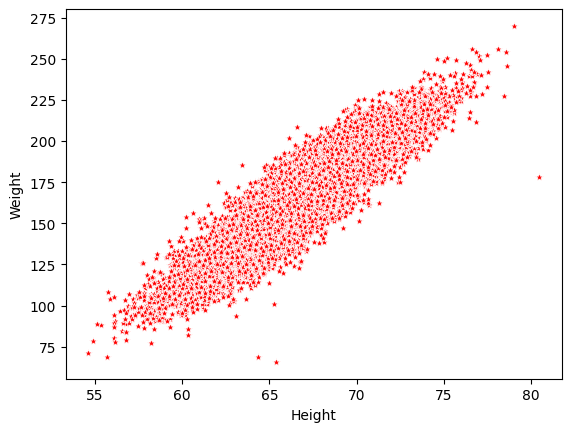

In [25]:
sns.scatterplot(x = df['Height'], y = df['Weight'], marker = '*', color = 'r')
plt.show()

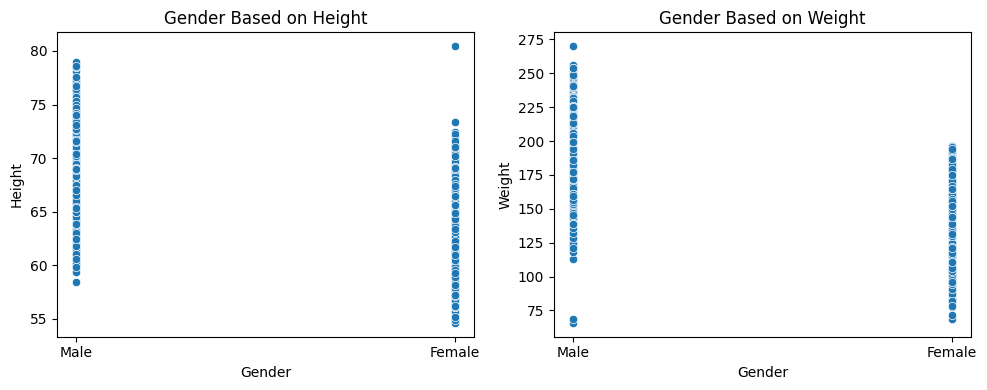

In [26]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.scatterplot(x = df['Gender'], y = df['Height'])
plt.title('Gender Based on Height')

plt.subplot(1,2,2)
sns.scatterplot(x = df['Gender'], y = df['Weight'])
plt.title('Gender Based on Weight')

plt.tight_layout()
plt.show()

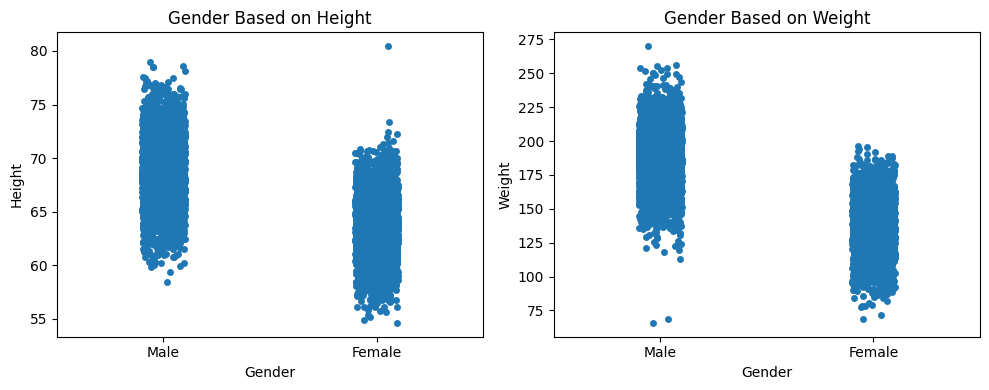

In [27]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.stripplot(x=df['Gender'], y=df['Height'])
plt.title('Gender Based on Height')

plt.subplot(1,2,2)
sns.stripplot(x=df['Gender'], y=df['Weight'])
plt.title('Gender Based on Weight')

plt.tight_layout()
plt.show()

C:\Users\Qbits\AppData\Local\Temp\ipykernel_4784\3501926915.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[['Height','Weight']],labels = ['Height','Weight'])


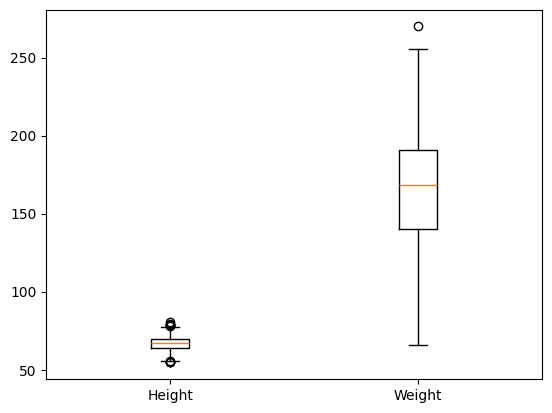

In [28]:
plt.boxplot(df[['Height','Weight']],labels = ['Height','Weight'])
plt.show()

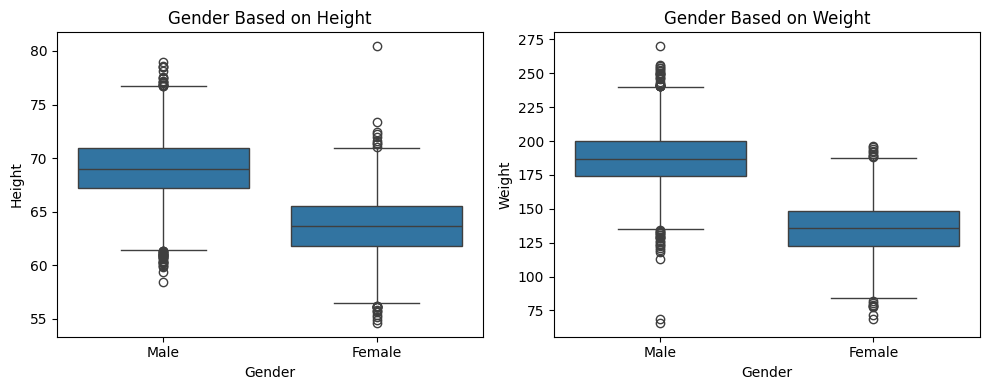

In [29]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['Gender'], y=df['Height'])
plt.title('Gender Based on Height')

plt.subplot(1,2,2)
sns.boxplot(x=df['Gender'], y=df['Weight'])
plt.title('Gender Based on Weight')

plt.tight_layout()
plt.show()

# Observations

## 1. Height Comparison
- The median height of males is higher than females.
- Male height is mostly concentrated around **67–71 inches**.
- Female height is mostly around **62–65 inches**.
- There are several outliers in both groups:
  - Some unusually short males (~59–61 inches).
  - Some unusually tall females (~71–72 inches).

## 2. Weight Comparison
- Males generally weigh more than females.
- The median weight of males is around **180–190 lbs**.
- The median weight of females is around **130–140 lbs**.
- Males show greater variation in weight than females.
- Some outliers are present:
  - Very low weight values (~65–75 lbs).
  - Very high male weights (~240–270 lbs).

## 3. Distribution Characteristics
- Male distributions are wider, indicating more variability.
- Female distributions are more compact.
- Outliers exist in both height and weight datasets.

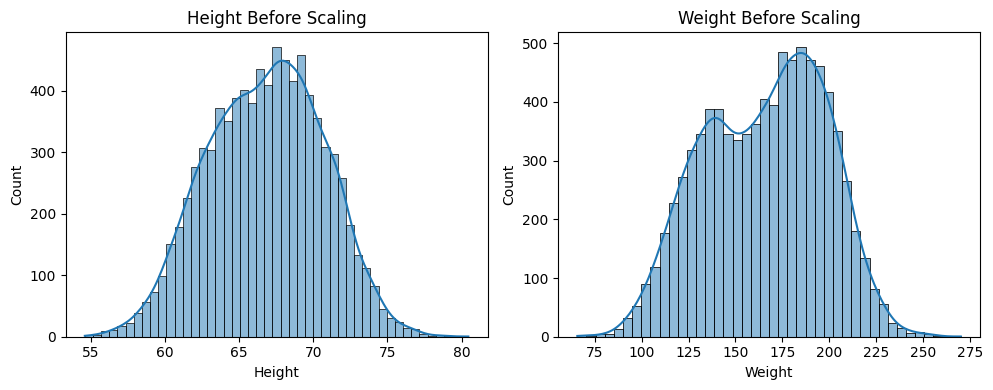

In [38]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Height'], kde=True)
plt.title("Height Before Scaling")

plt.subplot(1,2,2)
sns.histplot(df['Weight'], kde=True)
plt.title("Weight Before Scaling")

plt.tight_layout()
plt.show()

# Normalization or Scaling to remove outliers

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[['Height','Weight']] = scaler.fit_transform(df[['Height','Weight']])

In [50]:
df_scaled

,Gender,Height,Weight
0,Male,1.827233,2.380023
1,Male,0.512039,-0.103684
2,Male,1.895545,1.470197
3,Male,1.277788,1.698073
4,Male,0.797634,1.270738
...,...,...,...
8550,Female,-1.642587,-1.718593
8551,Female,-0.879344,-1.114506
8552,Female,-0.318306,-0.302417
8553,Female,0.161000,-0.435501


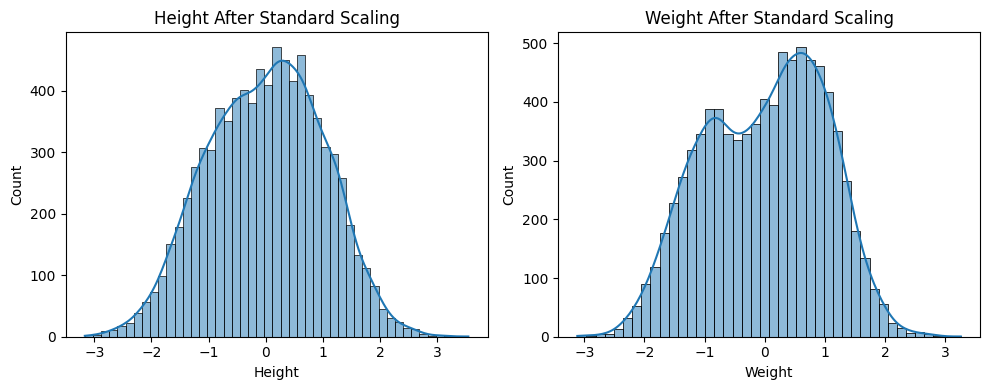

In [51]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_scaled['Height'], kde=True)
plt.title("Height After Standard Scaling")

plt.subplot(1,2,2)
sns.histplot(df_scaled['Weight'], kde=True)
plt.title("Weight After Standard Scaling")

plt.tight_layout()
plt.show()

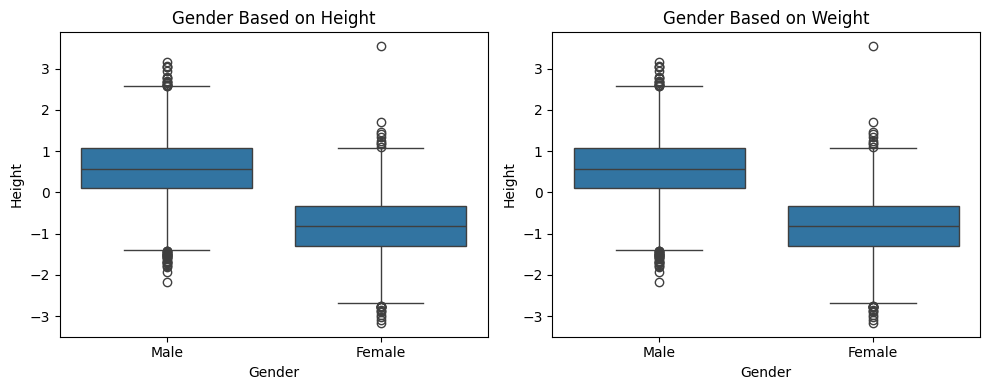

In [52]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df_scaled['Gender'], y=df_scaled['Height'])
plt.title('Gender Based on Height')

plt.subplot(1,2,2)
sns.boxplot(x=df_scaled['Gender'], y=df_scaled['Height'])
plt.title('Gender Based on Weight')

plt.tight_layout()
plt.show()

### Even after applying StandardScaler, outliers remain visible in the boxplot because scaling only standardizes the data distribution and does not remove extreme values. Since boxplots detect outliers based on the IQR method, the same extreme observations continue to appear as outliers after scaling.

In [53]:
# Encoding
df_scaled['Gender'] = df['Gender'].replace({'Male':0, 'Female': 1})


C:\Users\Qbits\AppData\Local\Temp\ipykernel_4784\3374142973.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_scaled['Gender'] = df['Gender'].replace({'Male':0, 'Female': 1})


In [54]:
df_scaled

,Gender,Height,Weight
0,0,1.827233,2.380023
1,0,0.512039,-0.103684
2,0,1.895545,1.470197
3,0,1.277788,1.698073
4,0,0.797634,1.270738
...,...,...,...
8550,1,-1.642587,-1.718593
8551,1,-0.879344,-1.114506
8552,1,-0.318306,-0.302417
8553,1,0.161000,-0.435501


In [55]:
x = df_scaled.iloc[:, 1:3]
x.head()

,Height,Weight
0,1.827233,2.380023
1,0.512039,-0.103684
2,1.895545,1.470197
3,1.277788,1.698073
4,0.797634,1.270738


In [56]:
y = df_scaled.iloc[:,0:1]
y.head()

,Gender
0,0
1,0
2,0
3,0
4,0


In [57]:
xtrain,xtest,ytrain,ytest = tts(x,y, test_size = 0.2, random_state = 42)

In [58]:
xtrain.head()

,Height,Weight
6826,-1.555954,-0.990987
624,1.272633,1.043880
5518,-0.814141,-0.966621
3946,0.949488,0.675691
6993,-1.371436,-1.497345


In [59]:
ytrain.head()

,Gender
6826,1
624,0
5518,1
3946,0
6993,1


In [60]:
xtest.head()

,Height,Weight
6006,-0.509780,-0.498232
1197,0.539163,0.998984
2862,1.078472,0.403172
6497,-1.057516,-0.758055
2860,0.718759,0.926593


In [61]:
ytest.head()

,Gender
6006,1
1197,0
2862,0
6497,1
2860,0


# Model Fit

## LogisticRegression

In [62]:
from sklearn.linear_model import LogisticRegression
lgr = LogisticRegression()
lgr.fit(xtrain,ytrain)

C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
lgr.score(xtrain, ytrain)

0.9162770309760374

In [64]:
lgr.score(xtest, ytest)

0.9222676797194623

In [83]:
y_pred_lgr = lgr.predict(xtest)
y_pred

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [66]:
lgr.predict_proba(xtest)

array([[0.24935521, 0.75064479],
       [0.99713265, 0.00286735],
       [0.81960423, 0.18039577],
       ...,
       [0.9400459 , 0.0599541 ],
       [0.99836376, 0.00163624],
       [0.63972114, 0.36027886]])

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score

In [84]:
print('Accuracy Score: ',accuracy_score(ytest,y_pred_lgr))
print('\nClassification Report: \n', classification_report(ytest, y_pred_lgr))
print('F1 Score : ',f1_score(ytest, y_pred_lgr))

Accuracy Score:  0.9222676797194623

Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      1005
           1       0.92      0.89      0.90       706

    accuracy                           0.92      1711
   macro avg       0.92      0.92      0.92      1711
weighted avg       0.92      0.92      0.92      1711

F1 Score :  0.904247660187185


In [85]:
cm = confusion_matrix(ytest, y_pred_lgr)
cm

array([[950,  55],
       [ 78, 628]], dtype=int64)

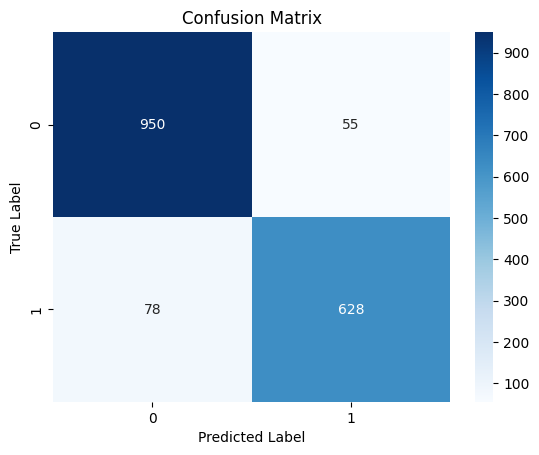

In [86]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [73]:
xtest.shape

(1711, 2)

# KNeighborsClassifier

In [75]:
from sklearn.neighbors import KNeighborsClassifier
knn_cf = KNeighborsClassifier(n_neighbors=5)
knn_cf.fit(xtrain, ytrain)

C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [98]:
print('Train score : ',knn_cf.score(xtrain,ytrain))
print('Test score: ',knn_cf.score(xtest,ytest))

Train score :  0.9177381648158971
Test score:  0.9246054938632379


In [88]:
y_pred_knn = knn_cf.predict(xtest)
y_pred_knn

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [92]:
print('Accuracy Score: ',accuracy_score(ytest,y_pred_knn))
print('\nClassification Report: \n', classification_report(ytest, y_pred_knn))
print('F1 Score : ',f1_score(ytest, y_pred_knn))
cm = confusion_matrix(ytest, y_pred_knn)
print('Confusion Matrix: \n', cm)

Accuracy Score:  0.9257744009351256

Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      1005
           1       0.92      0.90      0.91       706

    accuracy                           0.93      1711
   macro avg       0.93      0.92      0.92      1711
weighted avg       0.93      0.93      0.93      1711

F1 Score :  0.9086987778576564
Confusion Matrix: 
 [[952  53]
 [ 74 632]]


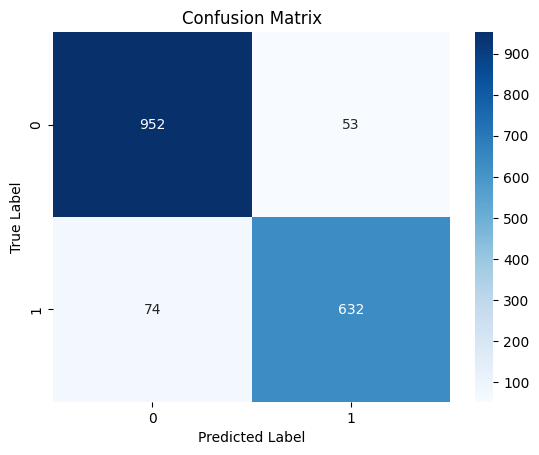

In [90]:
cm = confusion_matrix(ytest, y_pred_knn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [96]:
# hyperparameter tuning
accuracy_score_train_list = []
accuracy_score_test_list = []
f1_score_train_list = []
f1_score_test_list = []

for i in range(1,31):
    
    knn_cf = KNeighborsClassifier(n_neighbors=i)
    knn_cf.fit(xtrain, ytrain)
    
    print('K : ', i)
    
    # Train prediction
    y_pred_train = knn_cf.predict(xtrain)
    accuracy_train = accuracy_score(ytrain, y_pred_train)
    f1_train = f1_score(ytrain, y_pred_train)

    accuracy_score_train_list.append(accuracy_train)
    f1_score_train_list.append(f1_train)

    # Test prediction
    y_pred_test = knn_cf.predict(xtest)
    accuracy_test = accuracy_score(ytest, y_pred_test)
    f1_test = f1_score(ytest, y_pred_test)

    accuracy_score_test_list.append(accuracy_test)
    f1_score_test_list.append(f1_test)

    print("Accuracy Train:", accuracy_train, "Accuracy Test:", accuracy_test)
    print("F1 Train:", f1_train, "F1 Test:", f1_test)
    print()

# Find best K
import numpy as np
best_k = np.argmax(accuracy_score_test_list) + 1
print("Best K:", best_k)

C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y t

K :  1
Accuracy Train: 1.0 Accuracy Test: 0.8994739918176505
F1 Train: 1.0 F1 Test: 0.8760806916426513

K :  2
Accuracy Train: 0.9381940385739334 Accuracy Test: 0.8942139099941555
F1 Train: 0.9198104265402843 F1 Test: 0.8608762490392006

K :  3
Accuracy Train: 0.9362945645821157 Accuracy Test: 0.9210987726475746
F1 Train: 0.9232934553131598 F1 Test: 0.9030868628858578

K :  4
Accuracy Train: 0.9270894213909994 Accuracy Test: 0.9140853302162478
F1 Train: 0.9091240211254781 F1 Test: 0.8907063197026023

K :  5
Accuracy Train: 0.9263588544710696 Accuracy Test: 0.9257744009351256
F1 Train: 0.9115479115479116 F1 Test: 0.9086987778576564

K :  6
Accuracy Train: 0.9224137931034483 Accuracy Test: 0.9240210403272939
F1 Train: 0.9047875201721356 F1 Test: 0.9053857350800583

K :  7
Accuracy Train: 0.9222676797194623 Accuracy Test: 0.9275277615429574
F1 Train: 0.9065354884047786 F1 Test: 0.9111747851002865

K :  8


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y t

Accuracy Train: 0.9202220923436587 Accuracy Test: 0.9246054938632379
F1 Train: 0.9027084818246615 F1 Test: 0.9065894279507604

K :  9
Accuracy Train: 0.9200759789596727 Accuracy Test: 0.9263588544710696
F1 Train: 0.9038157200633022 F1 Test: 0.9097421203438395

K :  10
Accuracy Train: 0.9200759789596727 Accuracy Test: 0.9263588544710696
F1 Train: 0.9027901190687756 F1 Test: 0.9089595375722543

K :  11


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.9194915254237288 Accuracy Test: 0.9281122150789012
F1 Train: 0.9031464229214273 F1 Test: 0.9122055674518201

K :  12
Accuracy Train: 0.9194915254237288 Accuracy Test: 0.9275277615429574
F1 Train: 0.9022876396524206 F1 Test: 0.9106628242074928

K :  13
Accuracy Train: 0.9194915254237288 Accuracy Test: 0.9304500292226768
F1 Train: 0.9032484635645303 F1 Test: 0.9150606709493219

K :  14


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.918468731735827 Accuracy Test: 0.9298655756867329
F1 Train: 0.9012039660056658 F1 Test: 0.9136690647482014

K :  15
Accuracy Train: 0.9197837521917007 Accuracy Test: 0.9298655756867329
F1 Train: 0.9034640407947951 F1 Test: 0.9144079885877318

K :  16
Accuracy Train: 0.9187609585037989 Accuracy Test: 0.9310344827586207
F1 Train: 0.9016625397948355 F1 Test: 0.9152298850574713

K :  17


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.9199298655756867 Accuracy Test: 0.9292811221507891
F1 Train: 0.9037245256500351 F1 Test: 0.9137562366357804

K :  18
Accuracy Train: 0.9190531852717709 Accuracy Test: 0.9298655756867329
F1 Train: 0.9021892655367232 F1 Test: 0.9137931034482759

K :  19


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.9191992986557569 Accuracy Test: 0.9275277615429574
F1 Train: 0.9027948672877483 F1 Test: 0.9115549215406562

K :  20
Accuracy Train: 0.9193454120397428 Accuracy Test: 0.9292811221507891
F1 Train: 0.9026111503175723 F1 Test: 0.9132616487455197

K :  21


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.9197837521917007 Accuracy Test: 0.9281122150789012
F1 Train: 0.9035657825399613 F1 Test: 0.9125799573560768

K :  22
Accuracy Train: 0.918907071887785 Accuracy Test: 0.9275277615429574
F1 Train: 0.9020991356500264 F1 Test: 0.9113018597997139

K :  23


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.918614845119813 Accuracy Test: 0.9275277615429574
F1 Train: 0.9022292434614709 F1 Test: 0.9119318181818182

K :  24
Accuracy Train: 0.918614845119813 Accuracy Test: 0.9281122150789012
F1 Train: 0.9017809910068771 F1 Test: 0.9120800571837027

K :  25


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.918614845119813 Accuracy Test: 0.9269433080070134
F1 Train: 0.9021949078138718 F1 Test: 0.9111584932480455

K :  26
Accuracy Train: 0.918907071887785 Accuracy Test: 0.9257744009351256
F1 Train: 0.9022370970583055 F1 Test: 0.9092208720514653

K :  27


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.9180303915838691 Accuracy Test: 0.9275277615429574
F1 Train: 0.9013886447530322 F1 Test: 0.9116809116809117

K :  28
Accuracy Train: 0.9177381648158971 Accuracy Test: 0.9275277615429574
F1 Train: 0.9007929515418502 F1 Test: 0.9113018597997139

K :  29


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy Train: 0.918468731735827 Accuracy Test: 0.9257744009351256
F1 Train: 0.9020021074815595 F1 Test: 0.9096085409252669

K :  30
Accuracy Train: 0.9177381648158971 Accuracy Test: 0.9246054938632379
F1 Train: 0.9008628279626695 F1 Test: 0.9080541696364932

Best K: 16


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


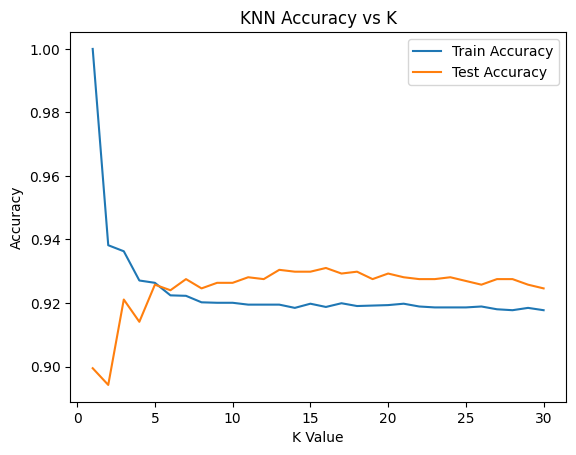

In [97]:
import matplotlib.pyplot as plt

plt.plot(range(1,31), accuracy_score_train_list, label="Train Accuracy")
plt.plot(range(1,31), accuracy_score_test_list, label="Test Accuracy")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.legend()
plt.show()

## Final KNeighborsClassifier Model after finding best k = 16

In [100]:
final_knn_cf = KNeighborsClassifier(n_neighbors = 16)
final_knn_cf.fit(xtrain, ytrain)

C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,16
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [102]:
print('Train score : ',final_knn_cf.score(xtrain,ytrain))
print('Test score: ',final_knn_cf.score(xtest,ytest))

Train score :  0.9187609585037989
Test score:  0.9310344827586207


In [103]:
y_pred_knn_final = final_knn_cf.predict(xtest)
y_pred_knn_final

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [104]:
print('Accuracy Score: ',accuracy_score(ytest,y_pred_knn_final))
print('\nClassification Report: \n', classification_report(ytest, y_pred_knn_final))
print('F1 Score : ',f1_score(ytest, y_pred_knn_final))

Accuracy Score:  0.9310344827586207

Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      1005
           1       0.93      0.90      0.92       706

    accuracy                           0.93      1711
   macro avg       0.93      0.93      0.93      1711
weighted avg       0.93      0.93      0.93      1711

F1 Score :  0.9152298850574713


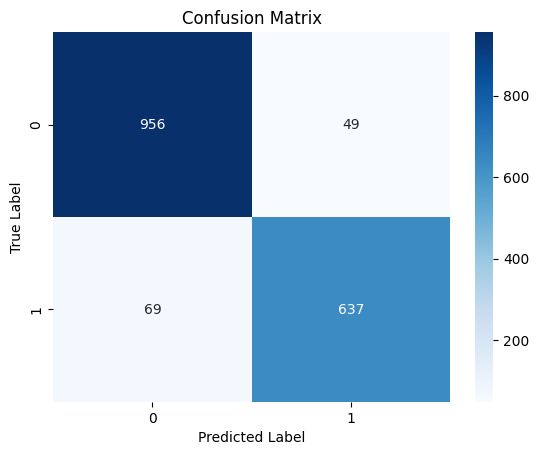

In [105]:
cm = confusion_matrix(ytest, y_pred_knn_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [107]:
from sklearn.model_selection import cross_val_score

lgr_scores = cross_val_score(lgr, x, y, cv=5, scoring='accuracy')
final_knn_cf = cross_val_score(final_knn_cf, x, y, cv=5, scoring='accuracy')

print("Logistic Regression CV Accuracy:", lgr_scores.mean())
print("KNN CV Accuracy:", final_knn_cf.mean())

C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_

Logistic Regression CV Accuracy: 0.9175920514319111
KNN CV Accuracy: 0.9173582700175336


C:\Program Files\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [108]:
print("LR Std:", lgr_scores.std())
print("KNN Std:", final_knn_cf.std())

LR Std: 0.006085056731651848
KNN Std: 0.005745508230248737
